<a href="https://colab.research.google.com/github/sergio191699-ship-it/Pr-cticas-Redes-Neuronales/blob/main/Clasificaci%C3%B3n_de_un_candidato_a_un_empleo_Practica_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generar dataset sintético con diferentes rangos por habilidad

In [1]:
import numpy as np
import pandas as pd

# Generar dataset sintético con diferentes rangos por habilidad
n_muestras = 5000
# Habilidades técnicas: 70-100
tec = np.random.randint(70, 101, (n_muestras, 6))
# Habilidades matemáticas: 60-90
mat = np.random.randint(60, 91, (n_muestras, 6))
# Habilidades psicológicas: 50-85
psi = np.random.randint(50, 86, (n_muestras, 6))
# Nombres de columnas
columnas = [
    'python', 'sql', 'visualizacion_datos', 'excel', 'manejo_apis', 'nube',
    'estadistica', 'probabilidad', 'algebra_lineal', 'calculo', 'optimizacion', 'modelado',
    'trabajo_equipo', 'comunicacion', 'creatividad', 'adaptabilidad', 'liderazgo', 'resolucion_problemas'
]
# Crear DataFrame
df = pd.DataFrame(np.concatenate([tec, mat, psi], axis=1), columns=columnas)

Obtenemos la etiqueta y

In [2]:
# Calcular promedio por grupo y promedio total
prom_tecnologicas = df[['python', 'sql', 'visualizacion_datos', 'excel', 'manejo_apis', 'nube']].mean(axis=1)
prom_matematicas  = df[['estadistica', 'probabilidad', 'algebra_lineal', 'calculo', 'optimizacion', 'modelado']].mean(axis=1)
prom_psicologicas = df[['trabajo_equipo', 'comunicacion', 'creatividad', 'adaptabilidad', 'liderazgo', 'resolucion_problemas']].mean(axis=1)
# Promedio total = promedio de los 3 promedios
prom_total = (prom_tecnologicas + prom_matematicas + prom_psicologicas) / 3
# Etiqueta: 1 = apto si promedio total > 80
y = (prom_total > 75).astype(int)
# one-hot encoding
y = pd.get_dummies(y).values

Obtenemos los conjuntos de entrenamiento y de test

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42
)

# Escalamiento
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Red neuronal

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
modelo = Sequential([
    Dense(64, input_shape=(X_train.shape[1],), activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')
])

adam = Adam(learning_rate=0.001)
modelo.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenamiento

In [5]:
history = modelo.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8068 - loss: 0.3743 - val_accuracy: 0.9470 - val_loss: 0.1213
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9694 - loss: 0.0775 - val_accuracy: 0.9550 - val_loss: 0.0975
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9770 - loss: 0.0569 - val_accuracy: 0.9640 - val_loss: 0.0897
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9871 - loss: 0.0368 - val_accuracy: 0.9630 - val_loss: 0.0898
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9884 - loss: 0.0307 - val_accuracy: 0.9690 - val_loss: 0.0705
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9877 - loss: 0.0271 - val_accuracy: 0.9660 - val_loss: 0.0745
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9924 - loss: 0.0202 - val_accuracy: 0.9660 - val_loss: 0.0922
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0.

Evaluación

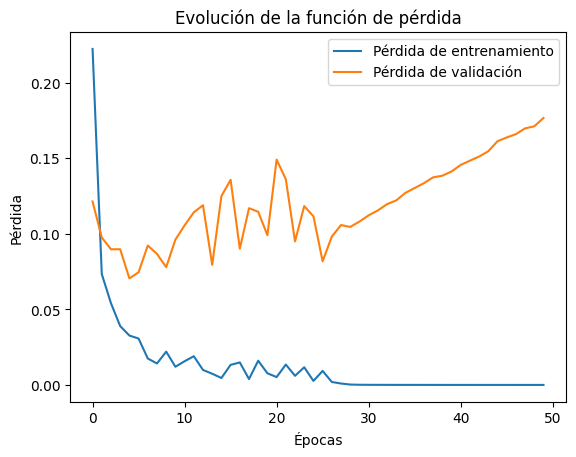

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9695 - loss: 0.1886

🔹 Loss: 0.1766  |  Accuracy: 0.9740


In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Evolución de la función de pérdida')
plt.show()

loss, acc = modelo.evaluate(X_test, y_test)
print(f"\n🔹 Loss: {loss:.4f}  |  Accuracy: {acc:.4f}")

Matriz de confusión

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


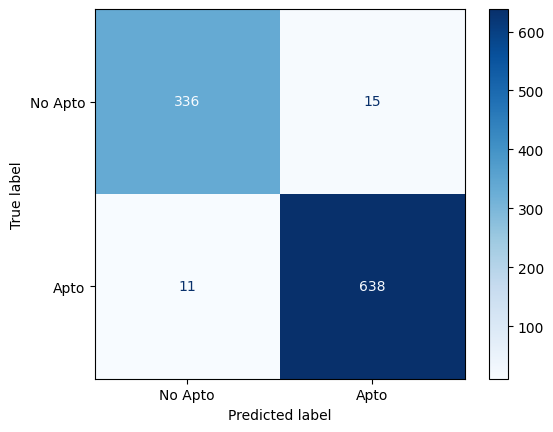


Sensitivity (Recall) por clase:
No Apto: 0.96
Apto: 0.98


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score

pred = modelo.predict(X_test)
y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Apto', 'Apto'])
disp.plot(cmap='Blues')
plt.show()

sensitivity = recall_score(y_true, y_pred, average=None)
print("\nSensitivity (Recall) por clase:")
print(f"No Apto: {sensitivity[0]:.2f}")
print(f"Apto: {sensitivity[1]:.2f}")

Evaluar un nuevo candidato

In [8]:
nuevo_candidato = np.array([[90, 88, 85, 87, 84, 89,   # técnicas
                             82, 86, 85, 83, 87, 80,   # matemáticas
                             70, 75, 80, 72, 78, 74]]) # psicológicas

nuevo_candidato_scaled = scaler.transform(nuevo_candidato)
pred_nuevo = modelo.predict(nuevo_candidato_scaled)
clase_predicha = np.argmax(pred_nuevo)

print("Evaluación de nuevo candidato:")
print(f"Resultado: {'Apto' if clase_predicha == 1 else 'No Apto'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Evaluación de nuevo candidato:
Resultado: Apto


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Clasificación de dígitos
Construiremos una red neuronal convolucional un ejemplo de una red neuronal convolucional (CNN) para clasificar dígitos escritos a mano en el conjunto de datos MNIST, que es un problema de clasificación de imágenes.

MNIST Dataset
Cargar el conjunto de datos MNIST de dígitos escritos a mano

In [11]:
from sklearn.datasets import load_digits

digits = load_digits()


Exploramos el dataset

In [10]:
digits.keys()


NameError: name 'digits' is not defined

El resultado es:

In [12]:
dict_keys([
    'data', 'target', 'frame',
    'feature_names', 'target_names', 'images',
    'DESCR'
])


NameError: name 'dict_keys' is not defined

Imprimimos la llave DESCR para obtener la información del conjuto de datos

In [13]:
print(digits.DESCR)


.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

Visualización de una imagen

Es necesario fijar el índice de la imagen que vamos a visualizar

In [14]:
index = 0


Obtener la imagen del dígito y su etiqueta

In [15]:
image = digits.images[index]
label = digits.target[index]


Imprimimos la representación matricial (numérica) de la imagen

In [16]:
print(image)


[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


Mostramos la imagen con Matplotlib

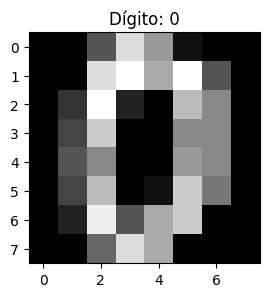

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))
plt.imshow(image, cmap=plt.cm.gray)
plt.title(f'Dígito: {label}')
plt.show()


Preprocesamiento de datos
Dividir los datos en conjuntos de entrenamiento y prueba

In [25]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target,
    test_size=0.2, random_state=42
)

#One-hot encode the target variable
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

NameError: name 'to_categorical' is not defined

Notemos la longitud del conjunto de entrenamiento y de test son respectivamente:

In [19]:
print(X_train.shape)
print(X_test.shape)

(1437, 64)
(360, 64)


Notamos como se ve el primer elemento de la variable X_train

In [20]:
reshaped_tensor = tf.reshape(X_train[0], shape=(8, 8))
print(reshaped_tensor)

tf.Tensor(
[[ 0.  0.  3. 14.  1.  0.  0.  0.]
 [ 0.  0. 12. 12.  0.  0.  0.  0.]
 [ 0.  3. 16.  6.  0.  0.  0.  0.]
 [ 0.  5. 16.  2.  0.  0.  0.  0.]
 [ 0.  6. 16.  2.  5.  2.  0.  0.]
 [ 0.  4. 16.  2. 12. 15.  2.  0.]
 [ 0.  1. 14. 13.  2. 13. 11.  0.]
 [ 0.  0.  3. 11. 16. 13.  4.  0.]], shape=(8, 8), dtype=float64)


Escalar las imágenes para normalizar los valores de píxeles

In [21]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalizar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

El StandardScaler y el MinMaxScaler son transformadores en la biblioteca scikit-learn que se utilizan para preprocesar los datos antes de alimentarlos a un modelo de aprendizaje automático. Ambos son métodos de escalado que ajustan los datos para que tengan ciertas propiedades que pueden mejorar el rendimiento del modelo.

StandardScaler:

El StandardScaler es utilizado para estandarizar características eliminando la media y escalando a la varianza unitaria.
Esto significa que, después de aplicar el StandardScaler, la media de cada característica será 0 y la varianza será 1.

El StandardScaler es útil cuando las características de entrada tienen distribuciones diferentes y varianzas diferentes. Por ejemplo, es común aplicar este escalado cuando se utilizan algoritmos que asumen que las características están centradas en 0 y tienen varianza en el mismo orden de magnitud.

MinMaxScaler:

El MinMaxScaler transforma las características escalándolas a un rango específico, generalmente entre 0 y 1.

El MinMaxScaler es útil cuando se quiere ajustar las características dentro de un rango específico o cuando se utilizan algoritmos sensibles a la escala de las características.

En resumen, el StandardScaler se utiliza para estandarizar las características a una media de 0 y varianza de 1, mientras que el MinMaxScaler se utiliza para escalar las características a un rango específico, generalmente entre 0 y 1.

Ahora notamos como se ve el primer elemento de la variable X_train después de la normalización

In [22]:
reshaped_tensor = tf.reshape(X_train[0], shape=(8, 8))
# Redondeamos para tener una mejor visualizacion
reshaped_tensor =  tf.floor(reshaped_tensor * 100) / 100
print(reshaped_tensor)

tf.Tensor(
[[ 0.   -0.35 -0.47  0.5  -2.55 -1.04 -0.41 -0.14]
 [-0.07 -0.62  0.3   0.   -2.19 -1.36 -0.53 -0.14]
 [-0.05  0.12  1.08 -0.2  -1.17 -1.28 -0.56 -0.12]
 [-0.04  0.86  1.13 -1.17 -1.61 -1.29 -0.63 -0.05]
 [ 0.    1.09  1.34 -1.13 -0.91 -1.14 -0.82  0.  ]
 [-0.07  0.82  1.39 -0.83  0.69  1.17 -0.34 -0.1 ]
 [-0.04  0.15  1.14  0.64 -1.43  0.68  1.47 -0.22]
 [-0.03 -0.31 -0.5  -0.25  0.84  1.05  0.45 -0.2 ]], shape=(8, 8), dtype=float64)


In [23]:
# Redimensionar el tensor a la forma (total, 8, 8)
X_train = tf.reshape(X_train, (X_train.shape[0], 8, 8))
X_test = tf.reshape(X_test, (X_test.shape[0], 8, 8))

Red neuronal convolucional

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# Crear el modelo de CNN
model = Sequential([
    Conv2D(32, kernel_size=(3, 3),
        activation='relu',
        input_shape=(8, 8, 1)
    ),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

Creamos un modelo secuencial de Keras, que es una pila lineal de capas. Este modelo incluye:

Una capa convolucional con 32 filtros, un tamaño de kernel de 3x3, y la función de activación ReLU.

Una capa de max pooling para reducir el tamaño espacial de la salida.

Una capa flatten para aplanar los datos antes de pasar a las capas densas.

Una capa densa con 128 unidades y la función de activación ReLU.

Una capa de salida densa con 10 unidades (una para cada clase) y la función de activación softmax.

Compilar el modelo
Crear un optimizador Adam con una tasa de aprendizaje del 0.001

In [26]:
from tensorflow.keras.optimizers import Adam

# Tasa de aprendizaje deseada
learning_rate = 0.001
adam_optimizer = Adam(learning_rate=learning_rate)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Se compila el modelo utilizando el optimizador Adam y la función de pérdida de entropía cruzada categórica dispersa (sparse_categorical_crossentropy) para la clasificación.

También se puede usar directamente el nombre del optimizador ('adam') en el argumento optimizer de la función compile.

Entrenar el modelo

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Se entrena el modelo en los datos de entrenamiento utilizando fit. Se especifica el número de épocas, el tamaño del lote y la proporción de validación para monitorear el rendimiento del modelo durante el entrenamiento.
Función de pérdida

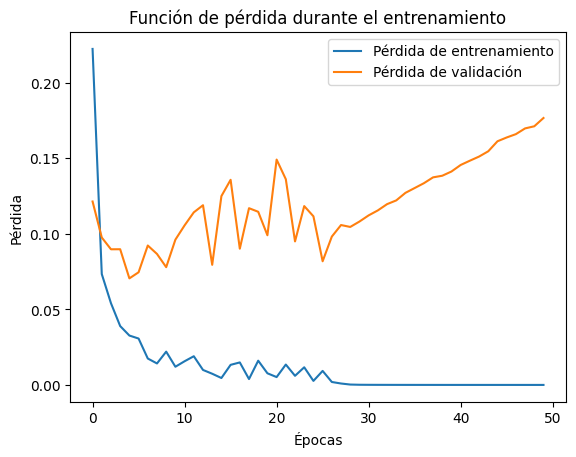

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Función de pérdida durante el entrenamiento')
plt.show()


Se nota que la función de pérdida debe tender hacia cero.

Evaluación
Evaluar el modelo en el conjunto de prueba

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

Se evalúa el rendimiento del modelo en el conjunto de prueba utilizando evaluate. Se obtienen la pérdida y la precisión del modelo en los datos de prueba.

Matriz de confusión y la sensibilidad (recall)

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, recall_score

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_classes)
sensitivity = recall_score(y_test, y_pred_classes, average=None)

Se calculan las predicciones del modelo en el conjunto de prueba y se obtienen las clases predichas. Se calcula la matriz de confusión utilizando confusion_matrix. Se calcula la sensibilidad (recall) para cada clase utilizando recall_score.

Visualizar la matriz de confusión y mostrar la sensibilidad para cada clase

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar la matriz de confusión como una imagen de colores
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Mostrar la sensibilidad (recall) para cada clase
print('Sensitivity (Recall) for each class:')
for i in range(10):
    print(f'Class {i}: {sensitivity[i]}')

Se visualiza la matriz de confusión como una imagen de colores utilizando sns.heatmap. Se muestra la sensibilidad (recall) para cada clase.

El recall mide la proporción de instancias positivas que fueron correctamente identificadas por el modelo sobre el total de instancias positivas en el conjunto de datos. En otras palabras, el recall indica qué tan efectivo es el modelo para encontrar todas las instancias positivas en comparación con el total de instancias positivas reales en el conjunto de datos.

Un recall de 1.0 (100%) significa que el modelo identifica todas las instancias positivas correctamente, es decir, no hay falsos negativos.

Un recall de 0.0 (0%) indica que el modelo no identifica ninguna instancia positiva correctamente, es decir, todos los casos positivos son clasificados como negativos (falsos negativos).

En resumen, un recall alto es deseable en problemas donde la detección de instancias positivas es crítica, mientras que un recall bajo puede indicar que el modelo necesita mejorar su capacidad para identificar verdaderos positivos.